# API Project - Bus Bunching
### Multi-agency Comparsion (WMATA, MBTA, MTA)
Question: What route and temporal factors are associated with bus bunching on high-frequency corridors, and do these relationships vary across different transit agencies (NYC, Boston, and DC)?

Washington Metropolitan Area Transit Authority (WMATA)
- High Frequency Routes: D40, D60, D80, C53, C61, D20, P40
- Low Frequency Routes: C81, P16, D24, P14, C23, P20, C35

Massachusetts Bay Transportation Authority (MBTA)
- High Frequency Routes: 1, 23, 28, 39, 57, 66, 111
- Low Frequency Routes: 64, 201, 50, 42, 87, 85, 70

Metropolitan Transportation Authority (MTA)
- High Frequency Routes: B44, B46, B41, BX12, M14A+, M23+, Q98
- Low Frequency Routes: B32, M21, BX42, M50, Q67, B84, Q42

In [54]:
#import libraries needed for API pull and data manipulation 
import pandas as pd
import numpy as np
import requests
import ratelim
import tenacity
import time
import os
import zipfile, io
from haversine import haversine as hav, Unit  #haversine: great-circle distance formula; Unit: specifies km/miles

In [55]:
path = "/Users/ahmadalexander/Desktop/python/eco590/final-project-Ahmad-Alexander/" #set file pathway

## **API**

In [56]:
WMATA_KEY = "5ec08fcd21744590b1a0f655710c4c91" #WMATA (DC) API Key
MBTA_KEY = '4aa18b9edd1341e383dc8fe55a788cca' #MBTA (Boston) API Key
MTA_KEY = '7027c575-3c63-477c-91d8-3d404472e8a0' #MTA (NYC) API Key

wmata_url = "https://api.wmata.com/Bus.svc/json/jBusPositions" #WMATA endpoint for live bus positions
mbta_url = "https://api-v3.mbta.com/vehicles" #MBTA endpoint for live vehicle positions
mta_url = "http://bustime.mta.info/api/siri/vehicle-monitoring.json" #MTA endpoint for live bus monitoring

wmata_headers = {"api_key": WMATA_KEY} #WMATA header for authentication 
mbta_headers = {"x-api-key": MBTA_KEY} #MBTA header for authentication 

In [57]:
#Bus routes used from each agency; high and low frequency rotues
wmata_routes = ['D40', 'D60', 'D80', 'C53', 'C61', 'D20', 'P40', 'C81', 'P16', 'D24', 'P14', 'C23', 'P20', 'C35']
mbta_routes = ['1', '23', '28', '39', '57', '66', '111', '64', '201', '50', '42', '87', '85', '70']
mta_routes = ['B44', 'B46', 'B41', 'BX12', 'M14A+', 'M23+', 'Q98', 'B32', 'M21', 'BX42', 'M50', 'Q67', 'B84', 'Q42'] #(+)suffix on routes denotes Select Bus Service (SBS) routes

In [58]:
#Renaming columns to match MTA & MBTA
wmata_fields = {
    'VehicleID': 'vehicle_id',
    'Lat': 'lat',
    'Lon': 'lon',
    'Deviation': 'deviation',
    'DateTime': 'timestamp',
    'TripID': 'trip_id',
    'RouteID': 'route_id',
    'DirectionNum': 'direction',
    'TripStartTime': 'trip_start_time'
}

In [59]:
output_dir = "data" #setting folder name
os.makedirs(output_dir, exist_ok=True)  #creating data folder to store csv (exist_ok=True will make sure there's no error if it already exists)

wmata_file = os.path.join(output_dir, "wmata.csv") #WMATA output csv
mbta_file = os.path.join(output_dir, "mbta.csv") #MBTA output csv
mta_file = os.path.join(output_dir, "mta.csv") #MTA output csv

poll_count = 0  #tracking number of polls for auto push to github

while True:
    try:
# WMATA
        try: #this allows for the loop to contuine if the pull fails for one agency
            wmata_dfs = [] #empty list to collect df for each route
            for route in wmata_routes: #loop through each WMATA route
                wmata_response = requests.get(wmata_url, params={"RouteID": route}, headers=wmata_headers) #API call for bus routes
                wmata_positions = wmata_response.json()['BusPositions'] #getting bus positions from JSON response
                if not wmata_positions:  # skip if no active vehicles
                    continue
                df = pd.DataFrame(wmata_positions)[list(wmata_fields.keys())].rename(columns=wmata_fields) #make df and rename columns
                df['agency'] = 'WMATA' #add agency label
                df['timestamp'] = pd.to_datetime(df['timestamp']) #convert timestamp string to datetime
                df['trip_start_time'] = pd.to_datetime(df['trip_start_time']) #convert trip start time string to datetime
                wmata_dfs.append(df) #add route df to the list
            if wmata_dfs:
                wmata_df = pd.concat(wmata_dfs, ignore_index=True) #combine all routes into one df
                wmata_df.to_csv(wmata_file, mode='a', header=not os.path.exists(wmata_file), index=False) #appending pulls to exsiting file
        except Exception as e:
            print(f"WMATA error: {e}") #if an error this will print it and move on

# MBTA
        try: #this allows for the loop to contuine if the pull fails for one agency
            mbta_dfs = [] #empty list to collect df for each route
            for route in mbta_routes: #loop through each MBTA route
                mbta_response = requests.get(mbta_url, params={"filter[route]": route}, headers=mbta_headers) #API call for bus routes
                mbta_vehicles = mbta_response.json().get('data', [])  #empty list if no active vehicles
                if not mbta_vehicles:  #skip if no active vehicles
                    continue
                mbta_fields = [] #empty list
                for vehicle in mbta_vehicles: #loop through each active vehicle on this route and pulls only the vars needed
                    row = {
                        'vehicle_id': vehicle['id'], 
                        'lat': vehicle['attributes']['latitude'],
                        'lon': vehicle['attributes']['longitude'],
                        'direction': vehicle['attributes']['direction_id'],
                        'timestamp': vehicle['attributes']['updated_at'],
                        'stop_sequence': vehicle['attributes']['current_stop_sequence'],
                        'trip_id': vehicle['relationships']['trip']['data']['id'],
                        'route_id': vehicle['relationships']['route']['data']['id']
                    }
                    mbta_fields.append(row)  #add this row to the list
                df = pd.DataFrame(mbta_fields) #add list to df
                if df.empty: #skip if no valid vehicles for this route
                    continue
                df['agency'] = 'MBTA' #add agency label
                df['timestamp'] = pd.to_datetime(df['timestamp']).dt.tz_localize(None)  #convert timestamp to datetime
                mbta_dfs.append(df) #add route df to list
            if mbta_dfs:
                mbta_df = pd.concat(mbta_dfs, ignore_index=True) #combine all routes into df
                mbta_df.to_csv(mbta_file, mode='a', header=not os.path.exists(mbta_file), index=False) #appending pulls to exsiting file
        except Exception as e:
            print(f"MBTA error: {e}") #if an error this will print it and move on

# MTA
        try: #this allows for the loop to contuine if the pull fails for one agency
            mta_dfs = [] #empty list
            for route in mta_routes: #loop through each MTA route
                mta_params = {"key": MTA_KEY, "LineRef": f"MTA NYCT_{route}"}  #LineRef is route-specific (needs to be in the loop)
                response = requests.get(mta_url, params=mta_params) #API call for bus routes
                delivery = response.json()['Siri']['ServiceDelivery']['VehicleMonitoringDelivery'][0] #nested JSON to vehicle delivery data
                mta_vehicles = delivery.get('VehicleActivity', [])  # empty list if no active vehicles
                mta_rows = [] #empty list to collect vehicle rows
                for vehicle in mta_vehicles: #loops through each active vehicle on this route
                    mvj = vehicle['MonitoredVehicleJourney']  # the path to data
                    if 'MonitoredCall' not in mvj:  #skip buses in layover
                        continue
                    mc = mvj['MonitoredCall']  #current stop info
                    if 'ExpectedArrivalTime' not in mc:  # skip vehicles with no prediction
                        continue
                    # parse both times so it can be subtracted to get dev
                    aimed = pd.to_datetime(mc['AimedArrivalTime']) #scheduled arrival time at current stop
                    expected = pd.to_datetime(mc['ExpectedArrivalTime']) #predicted arrival time at current stop
                    row = {
                        'vehicle_id': mvj['VehicleRef'].replace('MTA NYCT_', ''),  # removing prefix from vehicle id
                        'lat': mvj['VehicleLocation']['Latitude'],
                        'lon': mvj['VehicleLocation']['Longitude'],
                        'direction': int(mvj['DirectionRef']),  # making the string "0"/"1" to int
                        'timestamp': pd.to_datetime(vehicle['RecordedAtTime']),
                        'route_id': mvj['LineRef'].replace('MTA NYCT_', ''),  # removing prefix
                        'call_distance': mc['Extensions']['Distances']['CallDistanceAlongRoute'],  # stop_sequence equivalent
                        'deviation': (expected - aimed).total_seconds() / 60  # positive = late, negative = early, calc from predicted vs scheduled arrival
                    }
                    mta_rows.append(row) #add this vehicle's row to the list
                df = pd.DataFrame(mta_rows) #convert list to df
                if df.empty:  #skip if no valid vehicles for this route
                    continue
                df['agency'] = 'MTA' #add agency label
                df['timestamp'] = df['timestamp'].dt.tz_localize(None) #convert timestamp to datetime
                mta_dfs.append(df) #add this route's df to list
            if mta_dfs:
                mta_df = pd.concat(mta_dfs, ignore_index=True) #combine all routes into one df
                mta_df.to_csv(mta_file, mode='a', header=not os.path.exists(mta_file), index=False) #append to file
        except Exception as e:
            print(f"MTA error: {e}")

        poll_count += 1 #poll counter
        print(f"Poll complete: {pd.Timestamp.now().strftime('%H:%M:%S')} (poll {poll_count})") #print timestamp and poll number to track progress
            
        time.sleep(60)  # wait 1 minute before next poll

    #Interrupt Kernal to stop API pull
    except KeyboardInterrupt:
        print("Polling stopped.")
        break

Poll complete: 06:13:10 (poll 1)
Polling stopped.


## **Cleaning**

In [67]:
# Extisting API pull data
wmata = pd.read_csv(path+"data/wmata.csv")
mbta = pd.read_csv(path+"data/mbta.csv", low_memory=False)
mta = pd.read_csv(path+"data/mta.csv")

#### Washington Metropolitan Area Transit Authority (WMATA)

In [68]:
# Fix dtypes + drop dupes
wmata['timestamp'] = pd.to_datetime(wmata['timestamp']) #convert timestamp to datetime object
wmata['trip_start_time'] = pd.to_datetime(wmata['trip_start_time']) # convert trip start time to datetime object
wmata[['vehicle_id', 'trip_id']] = wmata[['vehicle_id', 'trip_id']].astype(str) #making into a string
wmata = wmata.drop_duplicates(subset=['vehicle_id', 'timestamp']).copy() # remove duplicate if same id for same timestamp

wmata['hour'] = wmata['timestamp'].dt.hour #getting hour from timestamp
wmata['day_of_week'] = wmata['timestamp'].dt.dayofweek #getting day of week from timestamp
wmata['peak'] = (wmata['hour'].between(7, 10) | wmata['hour'].between(16, 19)).astype(int) #peak hours 1 if AM peak (7-10) or PM peak (16-19), else 0
wmata['service_id'] = wmata['day_of_week'].map({0:9,1:9,2:10,3:9,4:6,5:8,6:2}) #map day of week to WMATA's static GTFS calendar
wmata['trip_start_timedelta'] = pd.to_timedelta(wmata['trip_start_time'].dt.strftime('%H:%M:%S')) #convert trip start time to (HH:MM:SS)

# Load Static GTFS
response = requests.get("https://api.wmata.com/gtfs/bus-gtfs-static.zip", headers=wmata_headers) #download WMATA static GTFS zip file from API
response.raise_for_status() #error if download failed
z = zipfile.ZipFile(io.BytesIO(response.content)) #read zip file
stop_times = pd.read_csv(z.open('stop_times.txt')) #scheduled stop times for all trips
trips      = pd.read_csv(z.open('trips.txt')) #trip metadata, links trip_id to route_id and service_id
calendar   = pd.read_csv(z.open('calendar.txt')) #service calendar, defines which service_ids run on which days
stops      = pd.read_csv(z.open('stops.txt')) #stop metadata, stop coordinates and names

# Filter trips to active service days and relevant routes
day_cols = ['monday','tuesday','wednesday','thursday','friday','saturday','sunday'] #list of day columns in calendar.txt
active_services = calendar.loc[calendar[day_cols].any(axis=1), 'service_id'] #getting service_ids for the days of the week
wmata_trips = trips.loc[
    trips['route_id'].isin(wmata_routes) & trips['service_id'].isin(active_services), #filtering to routes & active service days
    ['trip_id', 'route_id', 'direction_id', 'service_id'] #keep only needed columns
]

# Build scheduled headways from first stop of each trip, from static GTFS
scheduled = stop_times.merge(wmata_trips, on='trip_id') #join stop times to filtered trips to get route/direction/service
scheduled = scheduled[scheduled['stop_sequence'] == scheduled.groupby('trip_id')['stop_sequence'].transform('min')] #keep only the first stop of each trip, used as the trip departure time
scheduled['departure_time'] = pd.to_timedelta(scheduled['departure_time']) #convert departure time to timedelta
scheduled = scheduled.sort_values(['route_id', 'direction_id', 'service_id', 'departure_time']) #sort consecutive trips 
scheduled['scheduled_headway'] = (
    scheduled.groupby(['route_id', 'direction_id', 'service_id'])['departure_time'] #group route, direction, & service ID by departure time
    .diff().dt.total_seconds() / 60 #time between consecutive trip departures in minutes; this is the scheduled headway
)
scheduled = scheduled[['route_id', 'direction_id', 'service_id', 'departure_time', 'scheduled_headway']] #keeping only columns needed for the merge

# Merge, drop unmatched rows, build bunching flag
wmata = wmata.merge(scheduled,
    left_on=['route_id', 'direction', 'service_id', 'trip_start_timedelta'], #matching on route, direction, service day, and trip start time
    right_on=['route_id', 'direction_id', 'service_id', 'departure_time'], #columns in scheduled headway table
    how='left'
).dropna(subset=['scheduled_headway']) #drop rows with no matching scheduled headway

wmata['bunching'] = (wmata['deviation'] > wmata['scheduled_headway'] * 0.5).astype(int) #bunching, 1 if vehicle is more than half a headway behind schedule
wmata = wmata.drop(columns=['trip_start_timedelta', 'direction_id', 'departure_time']) #drop columns used only for merging

wmata.to_csv(path+"data/wmata_clean.csv", index=False) #save file

wmata_stop_times = stop_times #store stop_times
wmata_stops = stops #store stops
wmata_trips = trips #store trips

#### Massachusetts Bay Transportation Authority (MBTA)

In [69]:
# Load raw data
mbta = pd.read_csv(path+"data/mbta.csv", low_memory=False) #load raw MBTA vehicle position data from csv

# Filter, fix dtypes, drop nulls and dupes
mbta = mbta[mbta['route_id'].isin([int(r) for r in mbta_routes if r.isdigit()] + mbta_routes)].copy() #filter to MBTA routes
mbta['timestamp'] = pd.to_datetime(mbta['timestamp']) #convert timestamp to datetime object
mbta[['route_id', 'trip_id']] = mbta[['route_id', 'trip_id']].astype(str) #making into a string
mbta['stop_sequence'] = mbta['stop_sequence'].astype('Int64') #convert stop_sequence to int
mbta = mbta.dropna(subset=['stop_sequence']).drop_duplicates(subset=['vehicle_id', 'timestamp']).copy() #drop rows missing stop_sequence and remove duplicate if same id for same timestamp

# Time variables
mbta['hour'] = mbta['timestamp'].dt.hour #getting hour from timestamp
mbta['day_of_week'] = mbta['timestamp'].dt.dayofweek #getting day of week from timestamp
mbta['peak'] = (mbta['hour'].between(7, 10) | mbta['hour'].between(16, 19)).astype(int) #peak hours 1 if AM peak (7-10) or PM peak (16-19), else 0
mbta['day_type'] = mbta['day_of_week'].map({0:'weekday',1:'weekday',2:'weekday',3:'weekday',4:'friday',5:'saturday',6:'sunday'}) #map day of week to day type, friday separate due to MBTA schedule differences
mbta['time_of_day'] = pd.to_timedelta(mbta['timestamp'].dt.strftime('%H:%M:%S')) #extract time of day as timedelta

# Load archived GTFS
response = requests.get("https://cdn.mbtace.com/archive/20260401.zip", headers=mbta_headers) #download archived MBTA GTFS 
response.raise_for_status() #error if download failed
with open(path+"data/mbta_gtfs.zip", "wb") as f:
    f.write(response.content) #save zip
z = zipfile.ZipFile(path+"data/mbta_gtfs.zip") #read zip file
live_trips      = pd.read_csv(z.open('trips.txt'), low_memory=False) #trip metadata, links trip_id to route_id and service_id
live_stop_times = pd.read_csv(z.open('stop_times.txt'), low_memory=False) #scheduled stop times for all trips
live_calendar   = pd.read_csv(z.open('calendar.txt')) #service calendar, defines which service_ids run on which days
live_stops      = pd.read_csv(z.open('stops.txt'), low_memory=False) #stop metadata, stop coordinates and names

# Map day_type to calendar and filter trips to relevant routes
live_calendar['day_type'] = live_calendar['service_id'].apply(
    lambda x: 'saturday' if 'Saturday' in x else 'sunday' if 'Sunday' in x else 'friday' if 'fr1' in x else 'weekday'
) #check each service_id string for day keywords and assign matching day_type
live_trips_filtered = live_trips[live_trips['route_id'].isin([str(r) for r in mbta_routes])] #filter trips to relevant routes
live_trips_filtered = live_trips_filtered.merge(live_calendar[['service_id', 'day_type']], on='service_id') #attach day_type to each trip via service_id

# Build scheduled headways from first stop of each trip
live_scheduled = live_stop_times.merge(live_trips_filtered[['trip_id', 'route_id', 'direction_id', 'day_type']], on='trip_id') #join stop times to filtered trips to get route/direction/service
live_scheduled = live_scheduled[live_scheduled['stop_sequence'] == live_scheduled.groupby('trip_id')['stop_sequence'].transform('min')] #keep only the first stop of each trip, used as the trip departure time
live_scheduled = live_scheduled.drop_duplicates(subset=['route_id', 'direction_id', 'day_type', 'departure_time']) #remove duplicate departure times within the same route/direction/day_type
live_scheduled['departure_time'] = pd.to_timedelta(live_scheduled['departure_time']) #convert departure time to timedelta
live_scheduled = live_scheduled.sort_values(['route_id', 'direction_id', 'day_type', 'departure_time']) #sort consecutive trips
live_scheduled['scheduled_headway'] = (
    live_scheduled.groupby(['route_id', 'direction_id', 'day_type'])['departure_time']
    .diff().dt.total_seconds() / 60 #time between consecutive trip departures in minutes; this is the scheduled headway
)
live_scheduled = live_scheduled.rename(columns={'direction_id': 'direction'}) #rename to match mbta column name for merge
live_scheduled = live_scheduled[['route_id', 'direction', 'day_type', 'departure_time', 'scheduled_headway']] #keeping only columns needed for the merge

# Nearest-match merge on time of day, drop unmatched
mbta = pd.merge_asof(
    mbta.sort_values('time_of_day'),
    live_scheduled.sort_values('departure_time'),
    left_on='time_of_day',
    right_on='departure_time',
    by=['route_id', 'direction', 'day_type'],
    direction='nearest' #match each observation to the closest scheduled departure by time
).dropna(subset=['scheduled_headway']) #drop rows with no matching scheduled headway

# Merge scheduled arrival times and calc deviation
live_stop_sched = live_stop_times[['trip_id', 'stop_sequence', 'arrival_time']].copy() #extract scheduled arrival times per trip and stop
live_stop_sched['arrival_time'] = pd.to_timedelta(live_stop_sched['arrival_time']) #convert arrival time to timedelta

mbta['stop_sequence'] = mbta['stop_sequence'].astype(int) #convert back to regular int for merging
mbta = mbta.merge(live_stop_sched, on=['trip_id', 'stop_sequence'], how='left') #attach scheduled arrival time to each observation
mbta['deviation'] = (mbta['time_of_day'] - mbta['arrival_time']).dt.total_seconds() / 60 #positive = late, negative = early
mbta = mbta[(mbta['deviation'] > -60) & (mbta['deviation'] < 60)] #filter deviation outliers

# Bunching flag and cleanup
mbta['bunching'] = (mbta['deviation'] > mbta['scheduled_headway'] * 0.5).astype(int) #bunching, 1 if vehicle is more than half a headway behind schedule
mbta = mbta.drop(columns=['time_of_day', 'departure_time', 'arrival_time', 'day_type']) #drop columns used only for merging

mbta = mbta[mbta['scheduled_headway'] <= 90].copy() #remove headways over 90 minutes

mbta.to_csv(path+"data/mbta_clean.csv", index=False) #save file

mbta_stop_times = live_stop_times #store stop_times
mbta_stops      = live_stops #store stops
mbta_trips      = live_trips #store trips

#### Metropolitan Transportation Authority (MTA)

In [70]:
# Fix dtypes, filter deviation outliers, drop dupes
mta['timestamp'] = pd.to_datetime(mta['timestamp'], format='mixed') #convert timestamp to datetime object, format='mixed' handles inconsistent timestamp formats
mta['vehicle_id'] = mta['vehicle_id'].astype(str) #making into a string
mta = mta[(mta['deviation'] > -60) & (mta['deviation'] < 60)] #filter deviation outliers
mta = mta.drop_duplicates(subset=['vehicle_id', 'timestamp']).copy() #remove duplicate if same id for same timestamp

# Time variables
mta['hour'] = mta['timestamp'].dt.hour #getting hour from timestamp
mta['day_of_week'] = mta['timestamp'].dt.dayofweek #getting day of week from timestamp
mta['peak'] = (mta['hour'].between(7, 10) | mta['hour'].between(16, 19)).astype(int) #peak hours 1 if AM peak (7-10) or PM peak (16-19), else 0
mta['day_type'] = mta['day_of_week'].map({0:'weekday',1:'weekday',2:'weekday',3:'weekday',4:'weekday',5:'saturday',6:'sunday'}) #map day of week to day type
mta['time_of_day'] = pd.to_timedelta(mta['timestamp'].dt.strftime('%H:%M:%S')) #extract time of day as timedelta for nearest-match merge with scheduled departures

# Load Static GTFS — MTA splits by borough
urls = {
    'brooklyn':  "http://web.mta.info/developers/data/nyct/bus/google_transit_brooklyn.zip",
    'bronx':     "http://web.mta.info/developers/data/nyct/bus/google_transit_bronx.zip",
    'manhattan': "http://web.mta.info/developers/data/nyct/bus/google_transit_manhattan.zip",
    'queens':    "http://web.mta.info/developers/data/nyct/bus/google_transit_queens.zip"
} 
zips = {} #empty dict to store opened zip files per borough
for borough, url in urls.items(): #loop through each borough
    r = requests.get(url) #download GTFS zip for  borough
    r.raise_for_status() #error if download failed
    with open(path+f"data/mta_gtfs_{borough}.zip", "wb") as f:
        f.write(r.content) #save zip
    zips[borough] = zipfile.ZipFile(path+f"data/mta_gtfs_{borough}.zip") #open and store zip

# Load and combine trips, stop_times, calendar from all boroughs
mta_trips      = pd.concat([pd.read_csv(z.open('trips.txt')) for z in zips.values()], ignore_index=True) #combine trips from all boroughs into one df
mta_stop_times = pd.concat([pd.read_csv(z.open('stop_times.txt'), low_memory=False) for z in zips.values()], ignore_index=True) #combine stop times from all boroughs into one df
mta_calendar   = pd.concat([pd.read_csv(z.open('calendar.txt')) for z in zips.values()], ignore_index=True).drop_duplicates() #combine calendars and drop duplicate service entries shared across boroughs
mta_stops      = pd.concat([pd.read_csv(z.open('stops.txt')) for z in zips.values()], ignore_index=True).drop_duplicates(subset='stop_id') #combine stops and deduplicate on stop_id since stops may appear in multiple borough feeds

# Map day_type to calendar and filter trips to relevant routes
mta_calendar['day_type'] = mta_calendar['service_id'].apply(
    lambda x: 'saturday' if 'Saturday' in x else 'sunday' if 'Sunday' in x else 'weekday'
) #check each service_id string for day keywords and match day_type
mta_trips_filtered = mta_trips[mta_trips['route_id'].isin(mta_routes)] #filter trips to relevant routes
mta_trips_filtered = mta_trips_filtered.merge(mta_calendar[['service_id', 'day_type']], on='service_id') #attach day_type to each trip via service_id

# Build scheduled headways from first stop of each trip
mta_scheduled = mta_stop_times.merge(mta_trips_filtered[['trip_id', 'route_id', 'direction_id', 'day_type']], on='trip_id') #join stop times to filtered trips to get route/direction/service
mta_scheduled = mta_scheduled[mta_scheduled['stop_sequence'] == mta_scheduled.groupby('trip_id')['stop_sequence'].transform('min')] #keep only the first stop of each trip, used as the trip departure time
mta_scheduled = mta_scheduled.drop_duplicates(subset=['route_id', 'direction_id', 'day_type', 'departure_time']) #remove duplicate departure times within the same route/direction/day_type
mta_scheduled['departure_time'] = pd.to_timedelta(mta_scheduled['departure_time']) #convert departure time to timedelta
mta_scheduled = mta_scheduled.sort_values(['route_id', 'direction_id', 'day_type', 'departure_time']) #sort consecutive trips
mta_scheduled['scheduled_headway'] = (
    mta_scheduled.groupby(['route_id', 'direction_id', 'day_type'])['departure_time']
    .diff().dt.total_seconds() / 60 #time between consecutive trip departures in minutes; this is the scheduled headway
)
mta_scheduled = mta_scheduled.rename(columns={'direction_id': 'direction'}) #rename to match mta column name for merge
mta_scheduled = mta_scheduled[['trip_id', 'route_id', 'direction', 'day_type', 'departure_time', 'scheduled_headway']] #keeping only columns needed for the merge

# Nearest-match merge on time of day, drop unmatched
mta = pd.merge_asof(
    mta.sort_values('time_of_day'),
    mta_scheduled.sort_values('departure_time'),
    left_on='time_of_day',
    right_on='departure_time',
    by=['route_id', 'direction', 'day_type'],
    direction='nearest' #match each observation to the closest scheduled departure by time
).dropna(subset=['scheduled_headway']) #drop rows with no matching scheduled headway

# Bunching flag and cleanup
mta['bunching'] = (mta['deviation'] > mta['scheduled_headway'] * 0.5).astype(int) #bunching, 1 if vehicle is more than half a headway behind schedule
mta = mta.drop(columns=['time_of_day', 'departure_time', 'day_type']) #drop columns used only for merging

mta.to_csv(path+"data/mta_clean.csv", index=False) #save file
all_df = pd.concat([wmata, mbta, mta], ignore_index=True) #merge all agencies together

#### Calculating Timepoint Rate
 Timepoint rate is the share of stops on a route that are designated as official timing points; stops where buses are held to schedule rather than allowed to run early. A higher timepoint rate shows tighter schedule enforcement. It is calculated from the GTFS stop_times.txt, where each stop has a timepoint coded as 1 (timepoint) or 0 (no timepoint). The route level timepoint rate is the mean of this field across all stops on the route.

In [72]:
# Timepoint Rate Calc
def compute_route_stats(stop_times, stops, trips, routes):
    st = stop_times.merge(trips[['trip_id', 'route_id']], on='trip_id', how='left') #attach route_id to each stop time by trip_id
    st = st[st['route_id'].isin(routes)] #filter to routes
    stats = st.groupby('route_id').agg(
        n_stops=('stop_id', 'nunique'), #count unique stops per route
        timepoint_rate=('timepoint', 'mean') #share of stops designated as timepoints
    ).reset_index()
    st_coords = (st
        .merge(stops[['stop_id', 'stop_lat', 'stop_lon']], on='stop_id', how='left') #attach lat/lon to each stop
        .sort_values(['route_id', 'trip_id', 'stop_sequence']) #sort stop order within each trip
    )
    st_coords['lat_next'] = st_coords.groupby('trip_id')['stop_lat'].shift(-1) #get lat of next stop in the same trip
    st_coords['lon_next'] = st_coords.groupby('trip_id')['stop_lon'].shift(-1) #get lon of next stop in the same trip
    st_coords = st_coords.dropna(subset=['lat_next', 'lon_next']) #drop last stop of each trip since it has no next stop
    st_coords['segment_km'] = st_coords.apply(
        lambda r: hav((r['stop_lat'], r['stop_lon']),
                      (r['lat_next'], r['lon_next']),
                      unit=Unit.KILOMETERS), axis=1 #calc distance between consecutive stops
    )
    lengths = (st_coords
        .groupby(['route_id', 'trip_id'])['segment_km'].sum() #sum segment distances to get total trip length
        .reset_index()
        .groupby('route_id')['segment_km'].mean() #average trip length across all trips on the route
        .mul(0.621371) #convert km to miles
        .rename('route_length_mi')
        .reset_index()
    )
    return stats.merge(lengths, on='route_id', how='left') #combine stop stats and route length into one dataframe

wmata_stats = compute_route_stats(wmata_stop_times, wmata_stops, wmata_trips, wmata_routes) #compute route stats for WMATA
mbta_stats  = compute_route_stats(mbta_stop_times, mbta_stops, mbta_trips, mbta_routes) #compute route stats for MBTA
mta_stats   = compute_route_stats(mta_stop_times, mta_stops, mta_trips, mta_routes) #compute route stats for MTA
route_stats = pd.concat([wmata_stats, mbta_stats, mta_stats], ignore_index=True) #combine all three agencies into one dataframe
all_df = all_df.merge(route_stats, on='route_id', how='left') #attach route stats to main dataframe

In [114]:
# Cleaning up extreme values
rows_before = len(all_df) #store row count before filtering
all_df = all_df[
    (all_df['deviation'].abs() <= 30) & #remove deviations over 30 minutes in either direction
    (all_df['scheduled_headway'] > 0) & #remove zero or negative headways
    (all_df['scheduled_headway'] <= 60) #remove unrealistic headways over 60 minutes
]
#print(f"Rows removed: {rows_before - len(all_df)}") #rows dropped by filters
#print(f"Rows left: {len(all_df)}") #remaining rows after cleaning

# Headway CV per route: std/mean of scheduled_headway, routes near 0 have consistent spacing, higher values indicate indicate bunching near 1
headway_cv = (
    all_df.groupby('route_id')['scheduled_headway']
    .agg(headway_cv=lambda x: x.std() / x.mean()) #std divided by mean per route
    .reset_index()
)
all_df = all_df.merge(headway_cv, on='route_id', how='left') #attach headway cv to main dataframe
all_df.to_csv(path+"data/bus_bunching.csv", index=False) #save final df as a csv
all_df.to_csv(path+"data/bus_bunching.csv.gz", index=False, compression='gzip') #save final df csv as zip

#### **Descrpitive Statistics**

In [81]:
# Peak vs off-peak bunching by agency
##print(all_df.groupby(['agency', 'peak'])['bunching'].mean().unstack())

# Bunching by day of week
##print(all_df.groupby(['agency', 'day_of_week'])['bunching'].mean().unstack())

# Bunching by headway bucket
all_df['headway_bucket'] = pd.cut(all_df['scheduled_headway'], bins=[0, 10, 20, 30, 90], labels=['<10min', '10-20min', '20-30min', '30+min'])
##print(all_df.groupby(['agency', 'headway_bucket'], observed=True)['bunching'].mean().unstack())

# Deviation by direction and peak
##print(all_df.groupby(['agency', 'direction', 'peak'])['deviation'].mean().unstack())

# Route-level bunching
##print(all_df.groupby(['agency', 'route_id'])['bunching'].mean().sort_values(ascending=False).groupby(level=0).head(5))
##print(all_df.groupby(['agency', 'route_id'])['bunching'].mean().sort_values(ascending=True).groupby(level=0).head(5))

# Scheduled Consistency and Headway Variability 
##print(all_df.groupby(['agency'])['timepoint_rate'].mean()
##print(all_df.groupby('agency')[['timepoint_rate', 'headway_cv']].describe())

#### Bunching

**Agency:**
- MTA highest bunching rate (35%), MBTA (28%), WMATA lowest (20%)
- MBTA deviation closest to on time (mean 0.3 min late) — likely reflects their bus priority infrastructure on key routes
- MTA and WMATA both average ~3+ minutes late

**Peak vs off-peak:**
- Peak hours have higher bunching across all three agencies as expected
- WMATA shows biggest peak effect (18% → 22%), MBTA barely changes (27% → 29%)

**Day of week:**
- Sunday consistently lowest bunching across all agencies
- MBTA Wednesday/Thursday notably worse than other weekdays
- MTA Tuesday/Wednesday worst
- WMATA Tuesday stands out

**Scheduled headway:**
- Bunching drops dramatically as headway increases this is consistent across all three agencies
- High frequency routes (<10 min): 36-45% bunching
- Low frequency routes (30+ min): only 1-5% bunching

#### Deviation by Direction and Peak

**MBTA:**
- Direction 0 off-peak is essentially on time (mean -0.007 min) but jumps to 0.58 min late during peak
- Direction 1 is more consistently late regardless of peak period
- Suggests inbound/outbound is tied to peak congestion

**MTA:**
- Direction 0 consistently worse than direction 1 in both peak and off-peak
- Both directions actually run closer to schedule during peak, this counterintuitive
- Likely reflects schedule padding built into peak timetables to account for expected congestion

**WMATA:**
- Minimal difference between directions and between peak/off-peak
- Deviation is consistently ~3.1-3.5 minutes late regardless of time or direction
- Could reflect WMATA's more conservative schedule padding across the board

**Note:** Direction (0/1) is route specific and does not have a consistent geographic meaning across agencies.

#### Route-Level Bunching

**Worst bunching routes:**
- MTA B41 (Nostrand Ave, Brooklyn): 54% — worst across all three agencies
- MBTA 39 and 28 (Jamaica Plain/Roxbury corridors): 46% and 42%
- WMATA C53: 38%
- All worst routes are high-frequency 

**Best bunching routes:**
- WMATA P20, C23, P16: 2-5% — all low-frequency suburban routes
- MTA B84, Q42: 2-3% — low-frequency Queens/Brooklyn routes
- MBTA low-frequency routes (64, 50, 85): 13-19% — higher than WMATA equivalents

**MBTA anomaly:**
- MBTA has lowest average deviation but its low-frequency routes bunch more than WMATA equivalents
- This likely reflects denser urban operating environments on MBTA low-frequency corridors vs more suburban WMATA equivalents (will have to look into more)
- Scheduled headways are similar across agencies for low-frequency routes (~25-27 min)

#### Scheduled Consistency and Headway Variability 

**Timepoint Rate**
- MBTA mean of 0.034 is far below MTA (0.203) and WMATA (0.170), meaning MBTA operates with very little scheduled timepoints relative to total stops
- MTA has higher variance than WMATA (std 0.052 vs 0.036), suggesting more variability across its route network

**Headway CV**
- WMATA mean CV of 0.281 with tight std (0.080), routes are consistently evenly spaced across the network
- MBTA CV range is narrow (0.57–0.76), suggesting uniform bunching across its network rather than concentrated problem routes
- MBTA and MTA both average CV around 0.62–0.67, but MTA has a much higher variance (std 0.244 vs MBTA's 0.058)
- MTA max CV exceeds 1.0, indicating severe bunching

**Overall:**
- WMATA's low CV and tight std aligns with its low bunching rate (20%) and consistent deviation regardless of direction or peak
- MTA's high CV variance is consistent with B41 being an extreme outlier at 54% bunching
- MBTA's narrow CV range fits the Wednesday/Thursday anomaly, bunching is network wide rather than route specific

## Grahps & Charts

In [27]:
#Import libaires for graphing
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [102]:
outpath = "/Users/ahmadalexander/Desktop/python/eco590/final-project-Ahmad-Alexander/output/"

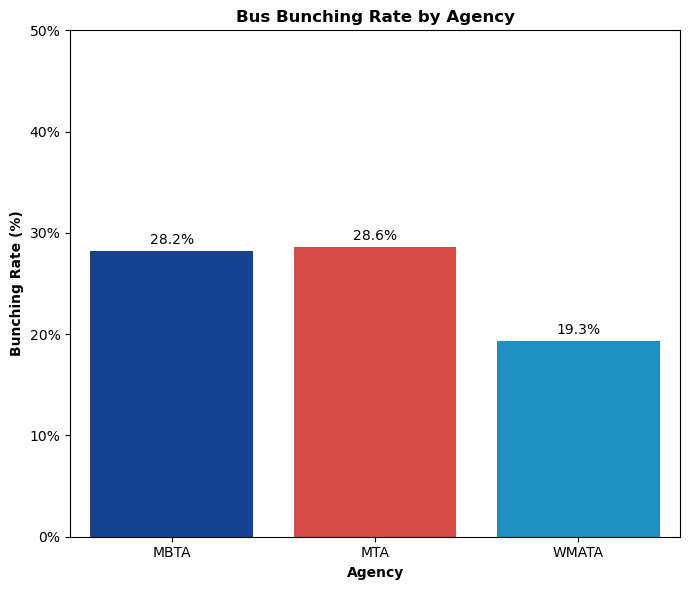

In [105]:
agency_bunching = all_df.groupby('agency')['bunching'].mean().reset_index() #calc mean bunching rate per agency
agency_bunching.columns = ['Agency', 'Bunching Rate'] #rename columns
agency_bunching['Bunching Rate'] = agency_bunching['Bunching Rate'] * 100 # making bunching rate a %

agency_colors = {'MBTA': '#003DA5', 'MTA': '#EE352E', 'WMATA': '#009CDE'} #colors by agency

fig, ax1 = plt.subplots(figsize=(7, 6)) #create figure and axes
sns.barplot(data=agency_bunching, x='Agency', y='Bunching Rate', ax=ax1, hue='Agency', palette=agency_colors, legend=False) #bar chart
ax1.set_title('Bus Bunching Rate by Agency', fontweight='bold') #chart title
ax1.set_xlabel('Agency', fontweight='bold') #x axis label
ax1.set_ylabel('Bunching Rate (%)', fontweight='bold') #y axis label
ax1.set_ylim(0, 50) #set y axis range to 0-50%
ax1.set_yticks(ax1.get_yticks()) #keep existing tick positions
ax1.set_yticklabels([f'{int(x)}%' for x in ax1.get_yticks()]) # adding % after values on y axis
for container in ax1.containers: # adding bunching rate % over bars (needs to be in a loop if using hue)
    ax1.bar_label(container, fmt='%.1f%%', padding=3) #formatting bar labels to one decimal place with % sign

plt.tight_layout() #adjust layout
plt.savefig(outpath + 'agencybunchingrate_graph.png', dpi=300, bbox_inches='tight') #save as png
plt.show() #display chart

### Conclusions:
MTA shows the highest bunching rate at 35%, followed by MBTA at 28.3% and WMATA at 20.2%. Suggesting there is meaningful variation in bus reliability across agencies, with NYC experiencing the most frequent bunching despite operating in a similar dense urban environment to Boston.

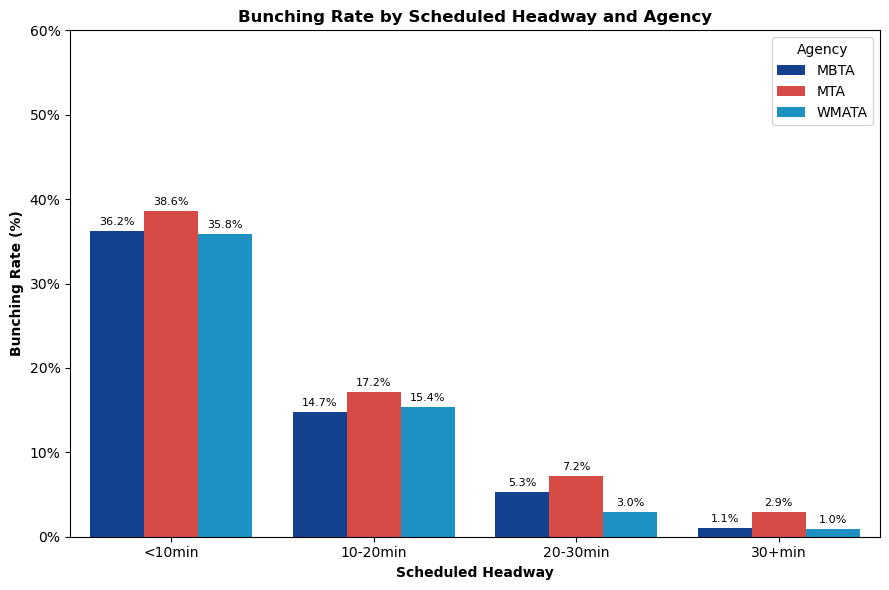

In [107]:

headway_bunching = all_df.groupby(['agency', 'headway_bucket'], observed=True)['bunching'].mean().reset_index() #calc mean bunching rate per agency and headway bucket
headway_bunching.columns = ['Agency', 'Headway', 'Bunching Rate'] #rename columns
headway_bunching['Bunching Rate'] = headway_bunching['Bunching Rate'] * 100 #convert bunching rate to %
headway_bunching['Headway'] = pd.Categorical(headway_bunching['Headway'], #set headway buckets so sorts correctly
                                              categories=['<10min', '10-20min', '20-30min', '30+min'], 
                                              ordered=True)
headway_bunching = headway_bunching.sort_values('Headway') #sort by headway order for correct bar placement

fig, ax2 = plt.subplots(figsize=(9, 6)) #create figure and axes
sns.barplot(data=headway_bunching, x='Headway', y='Bunching Rate', hue='Agency', #grouped bar chart by headway bucket
            palette=agency_colors, ax=ax2)

ax2.set_title('Bunching Rate by Scheduled Headway and Agency', fontweight='bold') #chart title
ax2.set_xlabel('Scheduled Headway', fontweight='bold') #x axis label
ax2.set_ylabel('Bunching Rate (%)', fontweight='bold') #y axis label
ax2.set_ylim(0, 55) #set y axis range to 0-55%
ax2.set_yticks(ax2.get_yticks()) #keep existing tick positions
ax2.set_yticklabels([f'{int(x)}%' for x in ax2.get_yticks()]) #adding % after values on y axis
ax2.legend(title='Agency') #add legend with agency label
for container in ax2.containers: #adding bunching rate % over bars
    ax2.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8) #format bar labels to one decimal place with % sign

plt.tight_layout() #adjust layout
plt.savefig(outpath + 'headwaybunchingrate_graph.png', dpi=300, bbox_inches='tight') #save as png
plt.show() #display chart

### Conclusions:
Bunching rates drop dramatically as scheduled headway increases across all three agencies, from 36-45% on high frequency routes (<10 min) to just 1.6-4.7% on low frequency routes (30+ min). Showing there is a consistent inverse relationship across all three agencies suggests that headway frequency is a structural predictor of bunching regardless of city or transit system.

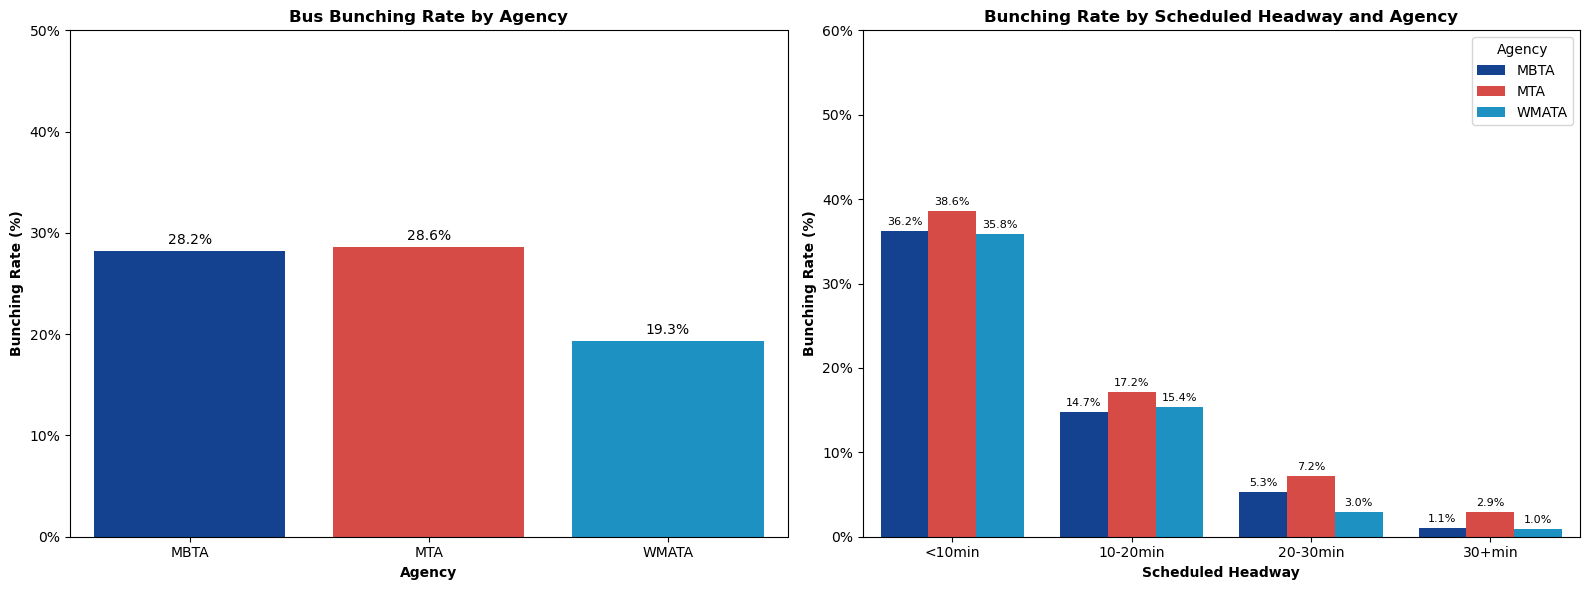

In [112]:
agency_bunching = all_df.groupby('agency')['bunching'].mean().reset_index() #calc mean bunching rate per agency
agency_bunching.columns = ['Agency', 'Bunching Rate'] #rename columns
agency_bunching['Bunching Rate'] = agency_bunching['Bunching Rate'] * 100 # making bunching rate a %

headway_bunching = all_df.groupby(['agency', 'headway_bucket'], observed=True)['bunching'].mean().reset_index() #calc mean bunching rate per agency and headway bucket
headway_bunching.columns = ['Agency', 'Headway', 'Bunching Rate'] #rename columns
headway_bunching['Bunching Rate'] = headway_bunching['Bunching Rate'] * 100 #convert bunching rate to %
headway_bunching['Headway'] = pd.Categorical(headway_bunching['Headway'], #set headway buckets so sorts correctly
                                              categories=['<10min', '10-20min', '20-30min', '30+min'], 
                                              ordered=True)
headway_bunching = headway_bunching.sort_values('Headway') #sort by headway order for correct bar placement

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6)) #create figure and axes
agency_colors = {'MBTA': '#003DA5', 'MTA': '#EE352E', 'WMATA': '#009CDE'} #colors by agency

# Graph 1: Agency Bunching
sns.barplot(data=agency_bunching, x='Agency', y='Bunching Rate', ax=ax1, hue='Agency', palette=agency_colors, legend=False) #bar chart
ax1.set_title('Bus Bunching Rate by Agency', fontweight='bold') #chart title
ax1.set_xlabel('Agency', fontweight='bold') #x axis label
ax1.set_ylabel('Bunching Rate (%)', fontweight='bold') #y axis label
ax1.set_ylim(0, 50) #set y axis range to 0-50%
ax1.set_yticks(ax1.get_yticks()) #keep existing tick positions
ax1.set_yticklabels([f'{int(x)}%' for x in ax1.get_yticks()]) # adding % after values on y axis
for container in ax1.containers: # adding bunching rate % over bars (needs to be in a loop if using hue)
    ax1.bar_label(container, fmt='%.1f%%', padding=3) #formatting bar labels to one decimal place with % sign

# Graph 2: Headway Bunching by Agency
sns.barplot(data=headway_bunching, x='Headway', y='Bunching Rate', hue='Agency', #grouped bar chart by headway bucket
            palette=agency_colors, ax=ax2)
ax2.set_title('Bunching Rate by Scheduled Headway and Agency', fontweight='bold') #chart title
ax2.set_xlabel('Scheduled Headway', fontweight='bold') #x axis label
ax2.set_ylabel('Bunching Rate (%)', fontweight='bold') #y axis label
ax2.set_ylim(0, 55) #set y axis range to 0-55%
ax2.set_yticks(ax2.get_yticks()) #keep existing tick positions
ax2.set_yticklabels([f'{int(x)}%' for x in ax2.get_yticks()]) #adding % after values on y axis
ax2.legend(title='Agency') #add legend with agency label
for container in ax2.containers: #adding bunching rate % over bars
    ax2.bar_label(container, fmt='%.1f%%', padding=3, fontsize=8) #format bar labels to one decimal place with % sign

plt.tight_layout() #adjust layout
plt.savefig(outpath + 'bunching_graphs.png', dpi=300, bbox_inches='tight') #save as png
plt.show() #display chart

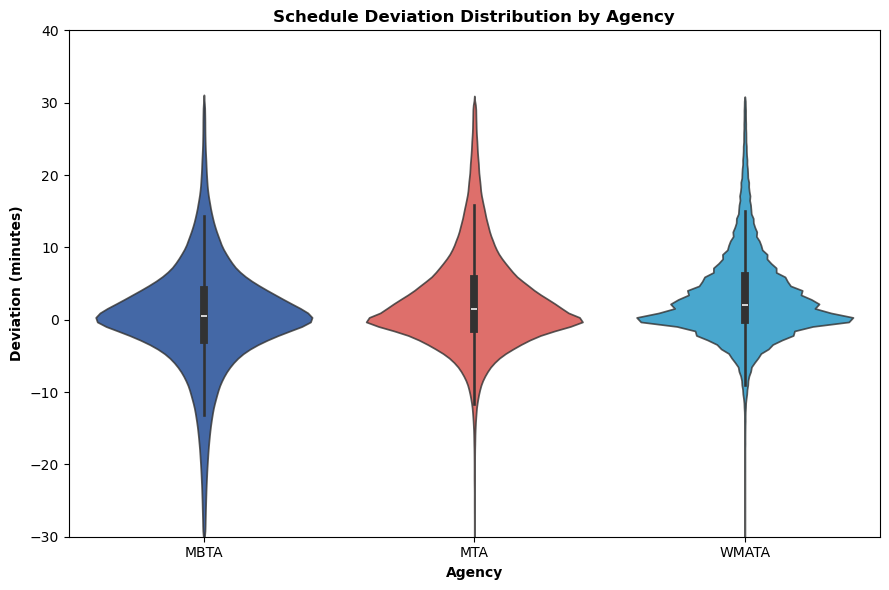

In [108]:
fig, ax3 = plt.subplots(figsize=(9, 6)) #create figure and axes
sns.violinplot(data=all_df, x='agency', y='deviation', hue='agency', #violin plot by agency
               palette=agency_colors, legend=False, ax=ax3, alpha=0.8, order=['MBTA', 'MTA', 'WMATA']) # alpha chnages transparency
ax3.set_ylim(-30, 40) #set y axis range
ax3.set_title('Schedule Deviation Distribution by Agency', fontweight='bold') #chart title
ax3.set_xlabel('Agency', fontweight='bold') #x axis label
ax3.set_ylabel('Deviation (minutes)', fontweight='bold') #y axis label

plt.tight_layout() #adjust layout
plt.savefig(outpath + 'scheduledeviation_graph.png', dpi=300, bbox_inches='tight') #save as png
plt.show() #display chart

### Conclusions:
- MBTA: Wider spread and extending further into negative territory meaning early buses (routes run ahead of schedule).
- MTA: The widest shape overall, bulges more on the positive side (meaning late), confirming MTA buses run the latest on average with the most variance
- WMATA: More narrow and shape centered just above 0, meaning most buses are close to on time with a relatively low variance; showing a much tighter distribution.

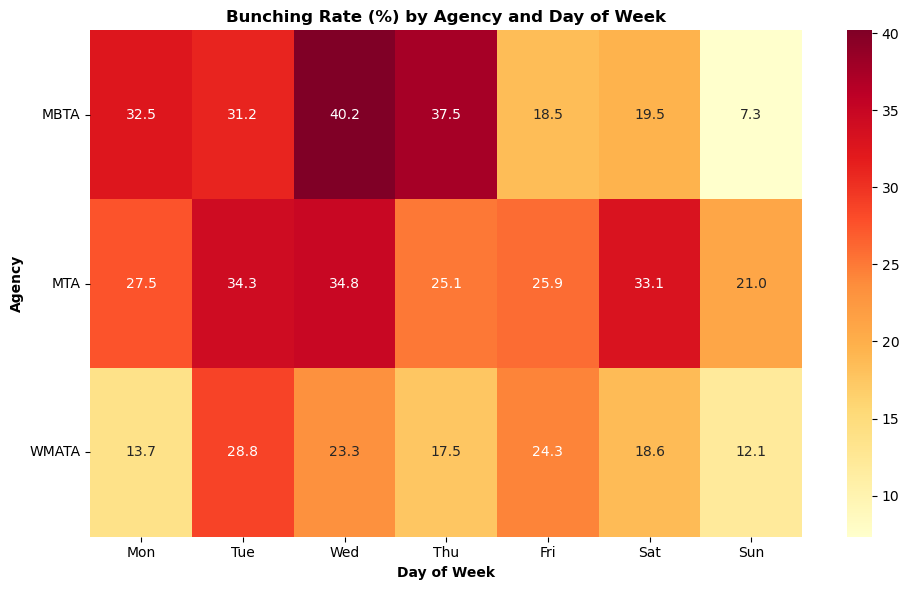

In [109]:
heatmap_data = all_df.groupby(['agency', 'day_of_week'])['bunching'].mean().unstack() * 100 #calc mean bunching rate by agency and day,  unstack day_of_week into columns, and convert to percentage
heatmap_data.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'] #rename columns

fig, ax4 = plt.subplots(figsize=(10, 6)) #create figure and axes
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax4) #heatmap
ax4.set_title('Bunching Rate (%) by Agency and Day of Week', fontweight='bold') #chart title
ax4.set_xlabel('Day of Week', fontweight='bold')  #x axis label
ax4.set_ylabel('Agency', fontweight='bold') #y axis label
ax4.set_yticks(ax4.get_yticks()) #keep existing tick positions
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0) #agency labels horizontal
plt.tight_layout() #adjust layout
plt.savefig(outpath + 'daybunchingrate_graph.png', dpi=300, bbox_inches='tight') #save as png
plt.show() #display chart

### Conclusions:
- Sunday is consistently the best day across all agencies, lowest bunching for all three (MBTA 7.5%, MTA 21.7%, WMATA 12.5%)
- MTA: Tuesday/Wednesday are the worst (42.8%, 43.4%) — mid-week peak in NYC bunching
- MBTA: Wednesday/Thursday spike (40.2%, 37.5%) then drops sharply on Friday, this is a rather unusual pattern  
- WMATA: Most inconsistent, Monday is surprisingly low (14.2%) but Tuesday jumps to 29.4%. Possibly due to WFH?
- Friday is interesting, MBTA drops to 18.9% while MTA stays high at 33.5% and WMATA increases to 25.6%

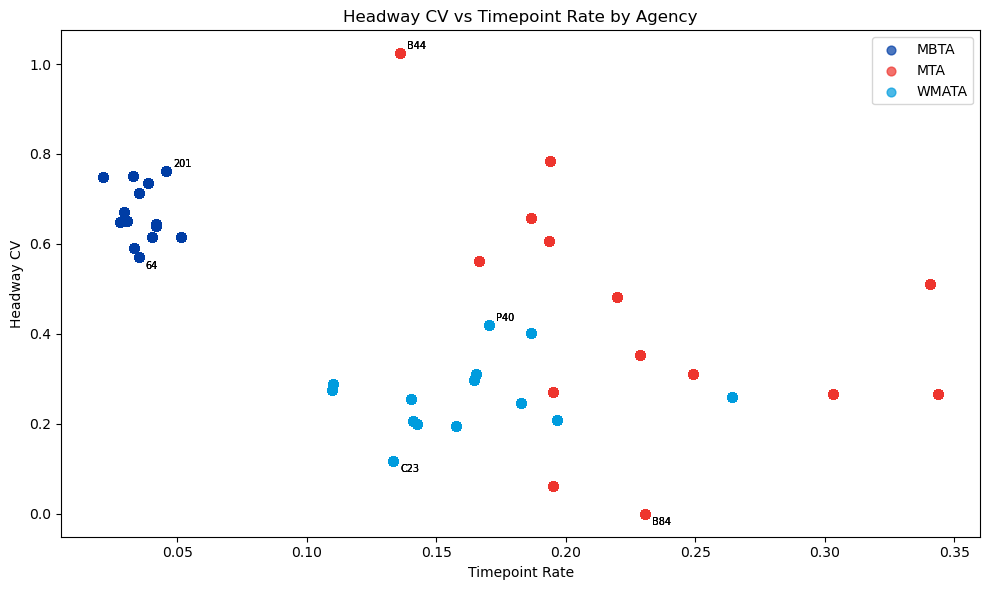

In [110]:
fig, ax5 = plt.subplots(figsize=(10, 6)) #create figure and axes
for agency, group in all_df.groupby('agency'): #loop through each agency to plot separately
    ax5.scatter(group['timepoint_rate'], group['headway_cv'],label=agency, color=agency_colors[agency], alpha=0.7, s=40) #scatter plot
    for _, row in group.nlargest(3, 'headway_cv').iterrows(): #loop through 3 routes with highest headway cv
        ax5.annotate(row['route_id'], (row['timepoint_rate'], row['headway_cv']),textcoords="offset points", xytext=(5, 3), fontsize=7) #label outlier routes above the point
    for _, row in group.nsmallest(3, 'headway_cv').iterrows(): #loop through 3 routes with lowest headway cv
        ax5.annotate(row['route_id'], (row['timepoint_rate'], row['headway_cv']),textcoords="offset points", xytext=(5, -8), fontsize=7) #label outlier routes below the point
ax5.set_xlabel('Timepoint Rate') #x axis label
ax5.set_ylabel('Headway CV') #y axis label
ax5.set_title('Headway CV vs Timepoint Rate by Agency') #chart title
ax5.legend() #add agency legend
plt.tight_layout() #adjust layout
plt.savefig(outpath+'headwayCV_vs_timepointR.png', dpi=300, bbox_inches='tight') #save as png
plt.show #display chart

### Conclusions:
- MBTA has low timepoint rates but high CV
- WMATA clusters at the bottom, more consistent headways - suggesting more timepoints does correlate with better spacing
- MTA has the widest spread, bunching is route specific, not system wide
- Overall: Higher timepoint rates are associated with more consistent headways